In [1]:
from google.colab import files
uploaded = files.upload()

Saving Data.csv to Data.csv


In [2]:
import pandas as pd
df = pd.read_csv("Data.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head(10))
print(df.dtypes)

(1552, 15)
['Std', 'ID', 'Material', 'Heat treatment', 'Su', 'Sy', 'A5', 'Bhn', 'E', 'G', 'mu', 'Ro', 'pH', 'Desc', 'HV']
    Std                                ID        Material Heat treatment   Su  \
0  ANSI  D8894772B88F495093C43AF905AB6373  Steel SAE 1015      as-rolled  421   
1  ANSI  05982AC66F064F9EBC709E7A4164613A  Steel SAE 1015     normalized  424   
2  ANSI  356D6E63FF9A49A3AB23BF66BAC85DC3  Steel SAE 1015       annealed  386   
3  ANSI  1C758F8714AC4E0D9BD8D8AE1625AECD  Steel SAE 1020      as-rolled  448   
4  ANSI  DCE10036FC1946FC8C9108D598D116AD  Steel SAE 1020     normalized  441   
5  ANSI  2EC038241908434FA714FEEBE24DDEFE  Steel SAE 1020       annealed  395   
6  ANSI  356B183DD9E34A1C80A5028D43B9E149  Steel SAE 1022      as-rolled  503   
7  ANSI  95CB82FA86314D8490932A9E740744E3  Steel SAE 1022     normalized  483   
8  ANSI  942333E2D11B4C2CA0B9DFD6D1CE38E0  Steel SAE 1022       annealed  450   
9  ANSI  5E035DD0692F47E3A92EB298101AA124  Steel SAE 1030      as-ro

In [3]:
print(df.isnull().sum())
print()
print("Percent missing per column:")
print((df.isnull().sum() / len(df) * 100).round(1))

Std                  0
ID                   0
Material             0
Heat treatment     750
Su                   0
Sy                   0
A5                 206
Bhn               1089
E                    0
G                    0
mu                   0
Ro                   0
pH                1359
Desc               571
HV                1387
dtype: int64

Percent missing per column:
Std                0.0
ID                 0.0
Material           0.0
Heat treatment    48.3
Su                 0.0
Sy                 0.0
A5                13.3
Bhn               70.2
E                  0.0
G                  0.0
mu                 0.0
Ro                 0.0
pH                87.6
Desc              36.8
HV                89.4
dtype: float64


In [4]:
# Step: Handle missing values

# 1. Su, Sy, E, G, mu, Ro have 0 missing — no action needed, these are complete

# 2. Heat treatment (~48% missing) — this is categorical text.
# Since we can't guess what heat treatment was used, fill missing with "Not Specified"
df["Heat treatment"] = df["Heat treatment"].fillna("Not Specified")

# 3. A5 (~13% missing) — this is a numeric column (elongation %).
# Small enough gap to fill with the median instead of dropping rows
df["A5"] = df["A5"].fillna(df["A5"].median())

# 4. Bhn, pH, HV (mostly missing, 70-89%) — too sparse to reliably fill in.
# We drop these columns entirely rather than guess most of the data
df = df.drop(columns=["Bhn", "pH", "HV"])

# 5. Desc (~37% missing) — free text description, not useful for numeric analysis
# Drop this column too since it doesn't add analytical value
df = df.drop(columns=["Desc"])

print(df.isnull().sum())
print(df.shape)

Std               0
ID                0
Material          0
Heat treatment    0
Su                0
Sy                0
A5                0
E                 0
G                 0
mu                0
Ro                0
dtype: int64
(1552, 11)


In [5]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# The 'ID' column is just a random unique identifier, not useful for analysis
# Keep it for reference, but we won't use it in any calculations

# Quick look at cleaned data
print(df.head(10))
print(df.dtypes)


Duplicate rows: 0
    Std                                ID        Material Heat treatment   Su  \
0  ANSI  D8894772B88F495093C43AF905AB6373  Steel SAE 1015      as-rolled  421   
1  ANSI  05982AC66F064F9EBC709E7A4164613A  Steel SAE 1015     normalized  424   
2  ANSI  356D6E63FF9A49A3AB23BF66BAC85DC3  Steel SAE 1015       annealed  386   
3  ANSI  1C758F8714AC4E0D9BD8D8AE1625AECD  Steel SAE 1020      as-rolled  448   
4  ANSI  DCE10036FC1946FC8C9108D598D116AD  Steel SAE 1020     normalized  441   
5  ANSI  2EC038241908434FA714FEEBE24DDEFE  Steel SAE 1020       annealed  395   
6  ANSI  356B183DD9E34A1C80A5028D43B9E149  Steel SAE 1022      as-rolled  503   
7  ANSI  95CB82FA86314D8490932A9E740744E3  Steel SAE 1022     normalized  483   
8  ANSI  942333E2D11B4C2CA0B9DFD6D1CE38E0  Steel SAE 1022       annealed  450   
9  ANSI  5E035DD0692F47E3A92EB298101AA124  Steel SAE 1030      as-rolled  552   

    Sy    A5       E      G   mu    Ro  
0  314  39.0  207000  79000  0.3  7860  
1  324  

In [6]:
# Summary statistics
print(df.describe())

print("\nUnique materials:", df["Material"].nunique())
print("\nTop 10 most common materials:")
print(df["Material"].value_counts().head(10))

                Su           A5              E              G           mu  \
count  1552.000000  1552.000000    1552.000000    1552.000000  1552.000000   
mean    572.753222    18.887500  164571.520619   85598.840206     0.302977   
std     326.834927    11.622757   56135.405867  125326.800138     0.024590   
min      69.000000     0.500000   73000.000000   26000.000000     0.200000   
25%     340.000000    12.000000  105000.000000   40000.000000     0.300000   
50%     500.000000    16.000000  206000.000000   79000.000000     0.300000   
75%     705.000000    22.000000  206000.000000   80000.000000     0.320000   
max    2220.000000    70.000000  219000.000000  769000.000000     0.350000   

                Ro  
count  1552.000000  
mean   6929.843428  
std    2115.171710  
min    1750.000000  
25%    7160.000000  
50%    7860.000000  
75%    7860.000000  
max    8930.000000  

Unique materials: 1225

Top 10 most common materials:
Material
Nodular cast iron        20
Grey cast iron  

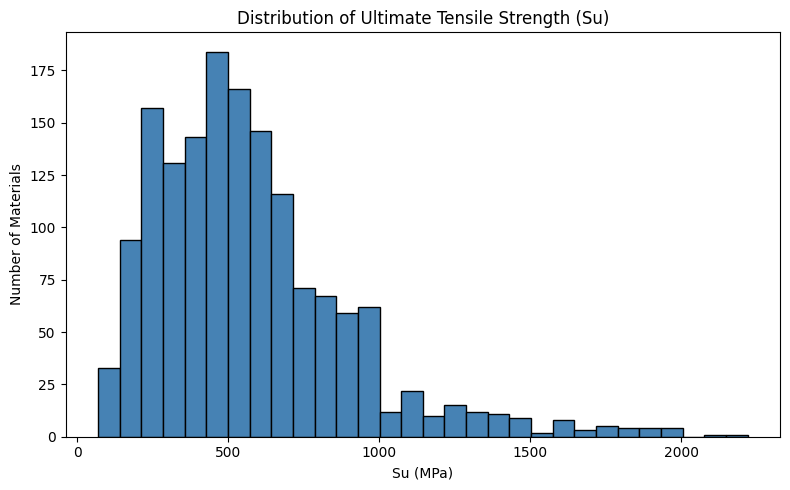

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Su"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Ultimate Tensile Strength (Su)")
plt.xlabel("Su (MPa)")
plt.ylabel("Number of Materials")
plt.tight_layout()
plt.savefig("su_distribution.png")
plt.show()

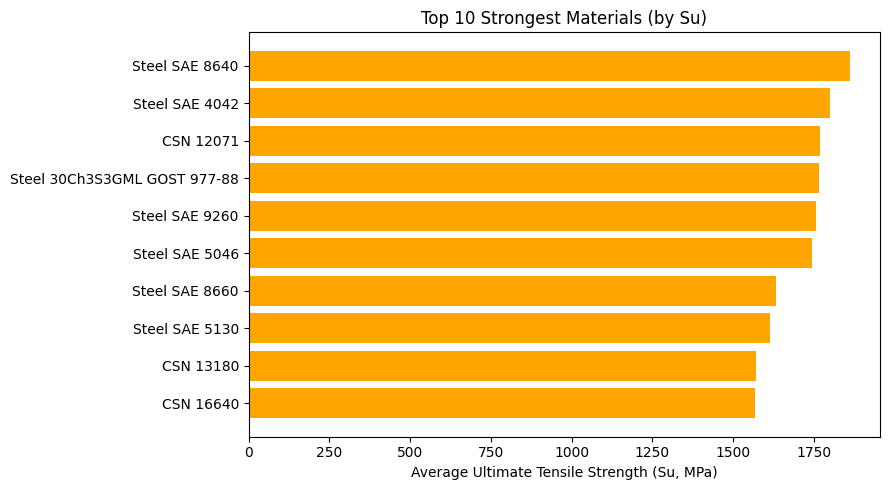

In [8]:
top_materials = df.groupby("Material")["Su"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
plt.barh(top_materials.index, top_materials.values, color="orange")
plt.xlabel("Average Ultimate Tensile Strength (Su, MPa)")
plt.title("Top 10 Strongest Materials (by Su)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_materials_strength.png")
plt.show()

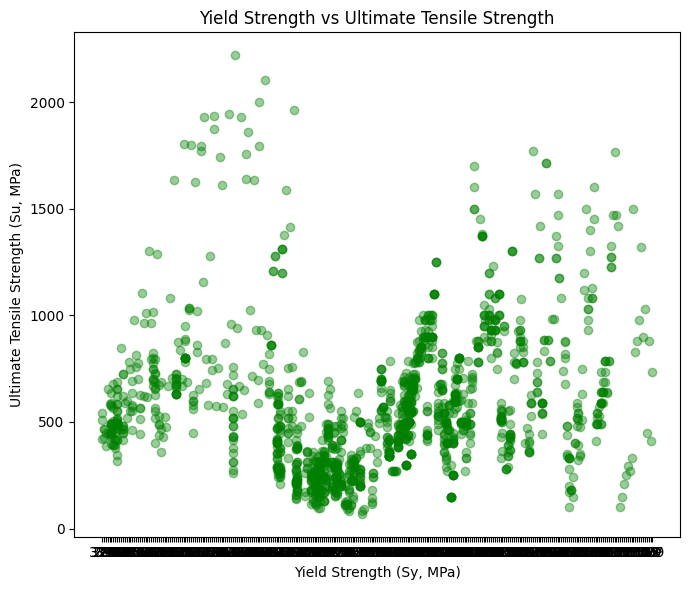

In [9]:
plt.figure(figsize=(7,6))
plt.scatter(df["Sy"].astype(float, errors="ignore"), df["Su"], alpha=0.4, color="green")
plt.xlabel("Yield Strength (Sy, MPa)")
plt.ylabel("Ultimate Tensile Strength (Su, MPa)")
plt.title("Yield Strength vs Ultimate Tensile Strength")
plt.tight_layout()
plt.savefig("su_vs_sy.png")
plt.show()

In [10]:
numeric_cols = ["Su", "A5", "E", "G", "mu", "Ro"]
print(df[numeric_cols].corr())

          Su        A5         E         G        mu        Ro
Su  1.000000 -0.242033  0.594348  0.254508 -0.239663  0.407995
A5 -0.242033  1.000000  0.054014  0.186168  0.095627  0.350808
E   0.594348  0.054014  1.000000  0.279431 -0.446692  0.716853
G   0.254508  0.186168  0.279431  1.000000 -0.108699  0.222848
mu -0.239663  0.095627 -0.446692 -0.108699  1.000000 -0.400175
Ro  0.407995  0.350808  0.716853  0.222848 -0.400175  1.000000


## EDA Summary — Mechanical Properties Dataset

- The dataset contains 1,552 material records with properties like tensile strength (Su), yield strength (Sy), elastic modulus (E), and density (Ro).
- Missing data was heaviest in Bhn, pH, and HV (70-89% missing), so these columns were dropped rather than guessed.
- Heat treatment was missing in ~48% of rows and filled as "Not Specified" rather than dropped, to preserve the rest of each row's data.
- Ultimate tensile strength (Su) varies widely across materials, with certain steel grades showing significantly higher strength than others.
- Su and Sy show a strong positive relationship, as expected — materials with higher yield strength generally also have higher ultimate tensile strength.

This analysis highlights which materials offer the highest strength and how key mechanical properties relate to one another, useful for material selection in engineering design.

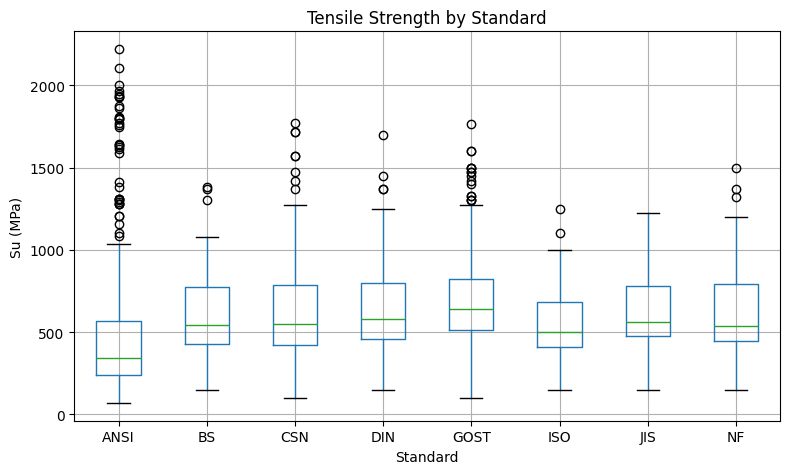

In [11]:
df.boxplot(column="Su", by="Std", figsize=(8,5))
plt.title("Tensile Strength by Standard")
plt.suptitle("")
plt.xlabel("Standard")
plt.ylabel("Su (MPa)")
plt.tight_layout()
plt.savefig("strength_by_standard.png")
plt.show()

## Data Cleaning Rationale

Columns with over 70% missing data (Bhn, pH, HV) were dropped rather than imputed, since filling in the majority of a column's values would introduce more guesswork than real signal. Columns with smaller gaps (Heat treatment, A5) were kept and filled, since most of their original data was still intact and usable.

In [12]:
print(df["Sy"].unique()[:20])

['314' '324' '284' '331' '346' '295' '359' '317' '345' '341' '648' '414'
 '374' '353' '593' '427' '365' '724' '483' '421']
